# Chapter 27: SHAP as a Feature Engineering Signal

**When two columns carry the same information, does the one with low attribution deserve to be dropped, and what does dropping both cost?**

Mean absolute SHAP is a common feature-selection screen, and copies of a signal are common in real tables. Measuring the attribution next to the removal tells you when a low value reflects redundancy rather than noise.

*Constructed data; the sizes of these effects are properties of this generator, not a competition result.*

## The experiment

Eight constructed datasets of 1,200 training rows with six columns. Columns A and B are two noisy readings of one hidden signal and correlate at the control value (1.0 is an identical copy); four more columns are pure noise. Only the signal drives the label. A histogram gradient boosting classifier is fitted, and exact Shapley values (by enumerating all 64 column subsets against 30 background rows) give mean absolute attribution on 100 validation rows. The copy ranked lower is then removed, then both copies, with a refit and the change in log loss measured on 6,000 fresh rows. Dropping one noise column is the control.

In [1]:
import itertools
import math

import numpy as np
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import log_loss

from kaggle_companion.activities._common import clean

SEED = 27
REPLICATES = 8             # independent constructed datasets; every estimate is their mean
P = 6                      # columns: copy A, copy B and four pure-noise columns
N_TRAIN, N_VALID, N_FRESH = 1200, 1200, 6000
EXPLAIN_ROWS, BACKGROUND_ROWS = 100, 30


def generate(n, copy_corr, rng):
    """Columns 0 and 1 are two noisy readings of one hidden signal z; they correlate at `copy_corr` (1 = identical).
    Only z drives the label, so either reading alone carries what the model needs."""
    z = rng.normal(size=n)
    s = math.sqrt(1.0 / copy_corr - 1.0)                       # reading noise that gives the requested correlation
    scale = math.sqrt(1.0 + s * s)                             # keep each reading at unit variance
    readings = [(z + s * rng.normal(size=n)) / scale for _ in range(2)]
    X = np.column_stack(readings + [rng.normal(size=n) for _ in range(P - 2)])
    y = (rng.random(n) < 1 / (1 + np.exp(-1.8 * z))).astype(int)
    return X, y


def fit(X, y, seed):
    return HistGradientBoostingClassifier(max_iter=60, max_leaf_nodes=8, min_samples_leaf=20,
                                          random_state=seed).fit(X, y)


SUBSETS = [S for k in range(P + 1) for S in itertools.combinations(range(P), k)]


def mean_abs_shap(model, rows, background):
    """Exact interventional Shapley values for P columns, in predicted-probability units.
    v(S) = mean prediction when columns in S come from the explained row and the others from background rows."""
    n_rows, n_bg = len(rows), len(background)
    value = {}
    for S in SUBSETS:
        hybrid = np.tile(background, (n_rows, 1))
        if S:
            hybrid[:, list(S)] = np.repeat(rows, n_bg, axis=0)[:, list(S)]
        value[S] = model.predict_proba(hybrid)[:, 1].reshape(n_rows, n_bg).mean(axis=1)
    phi = np.zeros((n_rows, P))
    for j in range(P):
        for S in SUBSETS:
            if j not in S:
                weight = math.factorial(len(S)) * math.factorial(P - len(S) - 1) / math.factorial(P)
                phi[:, j] += weight * (value[tuple(sorted(S + (j,)))] - value[S])
    return np.abs(phi).mean(axis=0)


def one_replicate(copy_corr, seed):
    rng = np.random.default_rng(seed)
    X, y = generate(N_TRAIN, copy_corr, rng)
    Xv, yv = generate(N_VALID, copy_corr, rng)
    Xf, yf = generate(N_FRESH, copy_corr, rng)                  # fresh rows from the same generator: the "truth"
    model = fit(X, y, seed)
    attribution = mean_abs_shap(model, Xv[:EXPLAIN_ROWS], X[:BACKGROUND_ROWS])
    low = int(np.argmin(attribution[:2]))                       # the copy the attribution ranks lower
    high = 1 - low

    def loss(cols):                                             # refit on the kept columns, score on both row sets
        m = fit(X[:, cols], y, seed)
        return (log_loss(yv, m.predict_proba(Xv[:, cols])[:, 1]), log_loss(yf, m.predict_proba(Xf[:, cols])[:, 1]))

    keep_all = list(range(P))
    full = loss(keep_all)
    removals = {"drop_noise": [c for c in keep_all if c != 2],  # control: one column that carries nothing
                "drop_low_copy": [c for c in keep_all if c != low],
                "drop_both": [c for c in keep_all if c > 1]}
    out = {name: [a - b for a, b in zip(loss(cols), full)] for name, cols in removals.items()}   # [validation, fresh]
    return {"attr_low": attribution[low], "attr_high": attribution[high], "attr_noise": float(attribution[2:].mean()),
            "low_is_column_a": low == 0, "full_fresh_loss": full[1], **out}


def run(copy_corr):
    reps = [one_replicate(copy_corr, SEED * 100 + i) for i in range(REPLICATES)]
    mean = lambda f: float(np.mean([f(x) for x in reps]))
    return clean({
        "copy_corr": copy_corr,
        "attr_low": mean(lambda x: x["attr_low"]), "attr_high": mean(lambda x: x["attr_high"]),
        "attr_noise": mean(lambda x: x["attr_noise"]),
        "low_is_column_a": int(sum(x["low_is_column_a"] for x in reps)),
        "full_fresh_loss": mean(lambda x: x["full_fresh_loss"]),
        **{f"{k}_fresh": mean(lambda x, k=k: x[k][1]) for k in ("drop_noise", "drop_low_copy", "drop_both")},
        **{f"{k}_valid": mean(lambda x, k=k: x[k][0]) for k in ("drop_noise", "drop_low_copy", "drop_both")},
        "per_replicate": {"attr_low": [x["attr_low"] for x in reps], "attr_high": [x["attr_high"] for x in reps],
                          **{f"{k}_fresh": [x[k][1] for x in reps] for k in ("drop_noise", "drop_low_copy", "drop_both")}},
        "replicates": REPLICATES, "train_rows": N_TRAIN, "fresh_rows": N_FRESH,
    })


## Measure it across the control

The control is **correlation between the two copies (1.0 = identical columns)**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch27 import explain

VALUES = [0.5, 0.9, 0.99, 1.0]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                               0.5     0.9    0.99     1.0
Higher copy |attribution|    0.128   0.159   0.170   0.265
Lower copy |attribution|     0.112   0.106   0.102   0.000
Noise column |attribution|   0.022   0.020   0.021   0.020
Drop low copy               +0.037  +0.012  +0.001   0.000
Drop both copies            +0.127  +0.193  +0.204  +0.206
Drop a noise column         -0.001  -0.001  -0.001   0.000


## Look at it

The figure shows the default setting, correlation between the two copies (1.0 = identical columns) = 1.0.

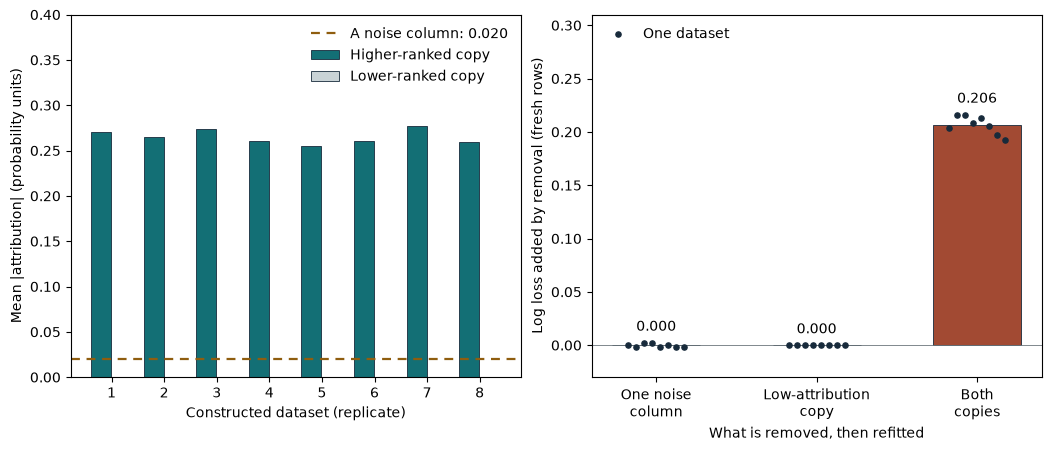

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch27 import draw, NCOLS, HEIGHT

DEFAULT = 1.0
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

At copy correlation 1.0: the higher-ranked copy has mean |attribution| 0.265 and the lower-ranked copy 0.000, against 0.020 for a noise column. The low copy ranks below a pure-noise column, so a screen would call it noise. Removing the low copy changes fresh-row log loss by 0.000; removing both copies changes it by +0.206, and 0.206 - 0.000 = 0.206 is the extra cost of dropping the pair. The lower-ranked copy was column A in 0 of 8 datasets.

- Share of the pair's attribution held by the low copy: 0.000 / (0.000 + 0.265) = 0.000.
- Cost of dropping the low copy: 0.000 log loss; a noise column: 0.000.
- Cost of dropping both: 0.206 - 0.000 = 0.206 beyond the single removal.
- Low copy was column A in 0 of 8 datasets (column order, not information, breaks a tie).

## Apply this to your competition

- Rank by mean |SHAP| across out-of-fold models, then list the columns that correlate with each low-ranked column before removing anything.
- Run the removal as paired experiments on the same development rows: remove the candidate alone, then the candidate with its substitutes.
- Keep a pure-noise column in the experiment so the cost of removing a useless column is measured, not assumed.
- Judge the selected subset on a separate assessment, and keep a failed removal in the experiment log.

Book location: Chapter 27, A Removal Contrast.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)